## Data scope: files and building/site used

### Input files loaded in this notebook
- `rawdata/Alarms/alarms.csv`
- `rawdata/Work orders/work_orders_anonymized 1.csv`
- `rawdata/Maintenance schedule (EH-työt)/Scheduled maitenance plans.csv`
- Occupancy CSVs loaded via glob from:
  - `rawdata/need-based cleaning/**/**desk_utilization*.csv`
  - `rawdata/need-based cleaning/**/**Room_Utilization*.csv`

### Building / site scope
- There is **no explicit single-building filter** in the code for alarms/work orders/plans.
- The analysis uses all rows from the loaded core datasets (multi-site scope, depending on source data content).
- Occupancy files currently resolve to the `Valmet Technologies Oy Lentokentänkatu 11` desk and room utilization folders under `rawdata/need-based cleaning/`.

# Luotea Hackathon: Alarms + Work Orders EDA

This notebook provides a clear first-pass workflow:
1. Load core datasets with robust settings
2. Profile quality and shape
3. Build first alarm-to-work-order linkage
4. Generate actionable baseline charts

In [18]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "rawdata").exists():
            return candidate
    raise RuntimeError("Could not find repository root containing rawdata/")

repo_root = find_repo_root(Path.cwd())
analysis_src = repo_root / "analysis" / "src"
if str(analysis_src) not in sys.path:
    sys.path.append(str(analysis_src))

from io_utils import load_csv
from profiling import basic_profile, column_quality

repo_root

PosixPath('/Users/jyri/repos/hack')

In [19]:
alarms_path = repo_root / "rawdata" / "Alarms" / "alarms.csv"
work_orders_path = repo_root / "rawdata" / "Work orders" / "work_orders_anonymized 1.csv"
plans_path = repo_root / "rawdata" / "Maintenance schedule (EH-työt)" / "Scheduled maitenance plans.csv"

df_alarms = load_csv(
    alarms_path,
    parse_dates=["ALERT_EVENT_LAST_UPDATED", "EVENT_TIME", "EVENT_CLOSED_TIME", "LOCATION_LAST_UPDATED"]
)

df_work = load_csv(
    work_orders_path,
    sep=";",
    parse_dates=[
        "WORK_STARTED_DATETIME",
        "WORK_FINISHED_DATETIME",
        "SLA_REQUIRED_START_DATETIME",
        "SLA_REQUIRED_END_DATETIME",
    ],
)

df_plans = load_csv(
    plans_path,
    parse_dates=["LAST_UPDATED", "LAST_CHANGED", "START_DATE", "REV_CRE_DATE", "VALID_FROM"],
)

for frame in (df_alarms, df_work, df_plans):
    if "CUSTOMER_NO" in frame.columns:
        frame["CUSTOMER_NO"] = frame["CUSTOMER_NO"].astype("string")
    if "CUSTOMER_SITE_NO" in frame.columns:
        frame["CUSTOMER_SITE_NO"] = frame["CUSTOMER_SITE_NO"].astype("string")

display(df_alarms.head(2))
display(df_work.head(2))
display(df_plans.head(2))

/Users/jyri/repos/hack/analysis/src/io_utils.py:34: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.read_csv(path, encoding=encoding, parse_dates=parse_dates, sep=sep)


,ALERT_EVENT_ID,ALERT_EVENT_LAST_UPDATED,CUSTOMER_NO,CUSTOMER_NAME,CUSTOMER_SITE_NO,CUSTOMER_SITE_NAME,SITE_ADDRESS,CONTRACT_NO,EVENT_TIME,ALERT_ID,EVENT_TYPE,HWID,HWID_TYPE,LOOP,ALERT_TYPE,Priority,LOG_ONLY,EVENT_DESCRIPTION,WORKORDER_NO,EVENT_CLOSED_TIME,LOCATION_ID,LOCATION_TABLE_ID,LOCATION_LAST_UPDATED,IVA_NO,STATUS
0,5701,2026-06-01 07:00:01.533,100000413,Valmet Technologies Oy,998389833,Lentokentänkatu 11,Lentokentänkatu 11 33900 Tampere FINLAND,10108694,2025-04-13 13:45:12,5162501,Hälytys,G00000005045,K2 vastaanotin,1,HÄLYT,60,NaN,"Sarankulman kiinteistö, PRI:1, PALAUTUNUT, 13....",NaN,2025-04-13 13:46:39,4218,4218,2026-06-01 07:00:01.063,5101,Valvonnassa
1,5702,2026-06-01 07:00:01.533,100000413,Valmet Technologies Oy,998389833,Lentokentänkatu 11,Lentokentänkatu 11 33900 Tampere FINLAND,10108694,2025-04-13 13:45:12,5162501,Hälytys,G00000005045,K2 vastaanotin,1,HÄLYT,60,NaN,"Sarankulman kiinteistö, PRI:1, PALAUTUNUT, 13....",NaN,2025-04-13 13:46:39,4219,4219,2026-06-01 07:00:01.063,5101,Valvonnassa


,CUSTOMER_NO,customer_name,CUSTOMER_SITE_NO,customer_site_name,site_address,CUSTOMER_WORKSITE_NO,CONTRACT_NO,CONTRACT,SERVICE_LINE_FIN,SERVICE_LINE_ENG,WO_NO,WO_PARENT_ID,WORK_ORDER_TYPE,WORK_ORDER_TYPE_ENG,ASSIGNMENT_TYPE,ASSIGNMENT_TYPE_ENG,PRIORITY_ID,WORK_DESCRIPTION,WORK_ORDER_DESCRIPTION,WORK_ORDER_PERFORMED_ACTION,WORK_TYPE_DESCRIPTION_FIN,WORK_TYPE_DESCRIPTION_ENG,PM_NO,PM_ACTION_DESCR,WORK_STARTED_DATETIME,WORK_FINISHED_DATETIME,WORK_FINISHED_DAYS,SLA_REQUIRED_START_DATETIME,SLA_REQUIRED_END_DATETIME,IS_SLA_VIOLATION,WORKTIME_HOURS,WORK_INVOICABLE,IS_SUBCONTRACTOR_WORK
0,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,10080373,108483.0,KIPA,Kiinteistöpalvelut,Facility services,42757853,3245874,Tilaustyö,On-demand work,Manuaalinen osoitus,Manually assigned,5.0,"Määräaikaishuollot, LV","Määräaikaishuollot, LV",Kohde: [NAME] 229 Tilattu työ: Määräaikaishuol...,Määräaikaishuollot lämpö ja vesi,Periodic maintenance heating and water systems,NaN,NaN,2.12.2019 10:00,4.12.2019 13:48,2.16.00,1.9.2019 0:00,NaT,1,1.98,EPÄTOSI,EPÄTOSI
1,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,10080373,108483.0,KIPA,Kiinteistöpalvelut,Facility services,43357347,3488144,Tilaustyö,On-demand work,Manuaalinen osoitus,Manually assigned,5.0,"Määräaikaishuollot, IV, kevät tavoitetunnit 61...","Määräaikaishuollot, IV, kevät",18.03.2020 Iv koneiden keväthuolto,Määräaikaishuollot ilmanvaihto,Periodic maintenance ventilation,NaN,NaN,13.3.2020 14:29,18.3.2020 15:29,5.04.00,1.3.2020 0:00,NaT,1,25.37,EPÄTOSI,EPÄTOSI


,LAST_UPDATED,PM_NO,MCH_CODE_CONTRACT,CUSTOMER_WORKSITE_NO,CUSTOMER_NO,customer_name,CUSTOMER_SITE_NO,customer_site_name,site_address,ACTION_DESCR,ACTION_DESCR_ENG,PRIORITY_ID,INTERVAL,PM_INTERVAL_UNIT,LAST_CHANGED,PLAN_HRS,DESCRIPTION,DESCRIPTION_ENG,START_DATE,REV_CRE_DATE,VALID_FROM,OBJSTATE
0,2022-05-03 04:19:20.580,430388,KH,10080373,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,Kattolumityöt,Roof snow removal,3,NaN,NaN,2022-05-02 09:34:06,0.66,Katoille ja räystäille kerääntyneen lumen ja j...,Monitoring of snow and ice accumulated on roof...,NaT,2020-12-16 08:40:45,2016-09-01,Obsolete
1,2022-05-03 04:19:20.580,430388,KH,10080373,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,Kattolumityöt,Roof snow removal,3,NaN,NaN,2022-05-02 09:34:06,0.66,Katoille ja räystäille kerääntyneen lumen ja j...,Monitoring of snow and ice accumulated on roof...,NaT,2020-12-16 08:40:45,2016-09-01,Obsolete


In [ ]:
summary = pd.concat([
    basic_profile(df_alarms, "alarms"),
    basic_profile(df_work, "work_orders"),
    basic_profile(df_plans, "maintenance_plans"),
], ignore_index=True)
summary

In [ ]:
column_quality(df_alarms).head(20)

In [ ]:
column_quality(df_work).head(20)

In [ ]:
top_priorities = df_alarms["Priority"].value_counts(dropna=False).head(10)
top_sites = df_alarms["CUSTOMER_SITE_NAME"].value_counts(dropna=False).head(10)
top_hwid = df_alarms["HWID"].value_counts(dropna=False).head(15)

display(top_priorities.to_frame("alarm_count"))
display(top_sites.to_frame("alarm_count"))
display(top_hwid.to_frame("alarm_count"))

In [ ]:
alarm_daily = (
    df_alarms.assign(day=df_alarms["EVENT_TIME"].dt.date)
    .groupby("day", dropna=True)
    .size()
    .rename("alarm_count")
    .reset_index()
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=alarm_daily, x="day", y="alarm_count")
plt.title("Daily Alarm Volume")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
wo_daily = (
    df_work.assign(day=df_work["WORK_STARTED_DATETIME"].dt.date)
    .groupby("day", dropna=True)
    .size()
    .rename("wo_count")
    .reset_index()
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=wo_daily, x="day", y="wo_count")
plt.title("Daily Work Order Starts")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Alarm to Work Order Linkage (Nearest Previous Alarm within 7 days)

This produces a conservative first linkage: for each work order, find the nearest previous alarm in the same customer and site within 7 days.

In [10]:
wo_link = df_work[[
    "WO_NO",
    "CUSTOMER_NO",
    "CUSTOMER_SITE_NO",
    "WORK_STARTED_DATETIME",
    "WORK_FINISHED_DATETIME",
    "PRIORITY_ID",
    "PM_NO",
]].copy()

# Ensure merge keys are typed correctly for merge_asof
wo_link["WORK_STARTED_DATETIME"] = pd.to_datetime(
    wo_link["WORK_STARTED_DATETIME"],
    errors="coerce",
    dayfirst=True,
)

alarm_link = df_alarms[[
    "ALERT_EVENT_ID",
    "CUSTOMER_NO",
    "CUSTOMER_SITE_NO",
    "EVENT_TIME",
    "Priority",
    "EVENT_DESCRIPTION",
    "HWID",
]].copy()

alarm_link["EVENT_TIME"] = pd.to_datetime(
    alarm_link["EVENT_TIME"],
    errors="coerce",
)

wo_link = wo_link.dropna(subset=["WORK_STARTED_DATETIME", "CUSTOMER_NO", "CUSTOMER_SITE_NO"])
alarm_link = alarm_link.dropna(subset=["EVENT_TIME", "CUSTOMER_NO", "CUSTOMER_SITE_NO"])

# merge_asof requires both frames sorted by the merge key (time)
wo_link = wo_link.sort_values(["WORK_STARTED_DATETIME", "CUSTOMER_NO", "CUSTOMER_SITE_NO"])
alarm_link = alarm_link.sort_values(["EVENT_TIME", "CUSTOMER_NO", "CUSTOMER_SITE_NO"])

linked = pd.merge_asof(
    wo_link,
    alarm_link,
    by=["CUSTOMER_NO", "CUSTOMER_SITE_NO"],
    left_on="WORK_STARTED_DATETIME",
    right_on="EVENT_TIME",
    direction="backward",
    tolerance=pd.Timedelta(days=7),
)

linked["response_hours"] = (
    linked["WORK_STARTED_DATETIME"] - linked["EVENT_TIME"]
).dt.total_seconds() / 3600

coverage = linked["ALERT_EVENT_ID"].notna().mean() * 100
print(f"Linked work order coverage (<=7d): {coverage:.1f}%")
linked.head()

Linked work order coverage (<=7d): 13.9%


,WO_NO,CUSTOMER_NO,CUSTOMER_SITE_NO,WORK_STARTED_DATETIME,WORK_FINISHED_DATETIME,PRIORITY_ID,PM_NO,ALERT_EVENT_ID,EVENT_TIME,Priority,EVENT_DESCRIPTION,HWID,response_hours
0,156837,100279959,999154922,2017-05-29 07:51:00,29.5.2017 14:24,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1,156894,100279959,999154922,2017-05-29 08:09:00,29.5.2017 8:10,1.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN
2,157202,100279959,999154922,2017-05-29 14:22:00,29.5.2017 14:22,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN
3,159691,100279959,999154922,2017-05-30 07:40:00,30.5.2017 9:59,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN
4,160564,100279959,999154922,2017-05-30 10:10:00,30.5.2017 10:28,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN


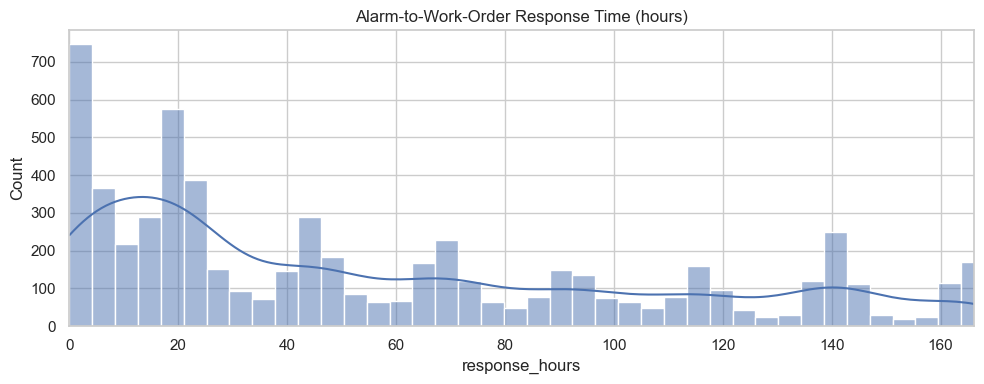

count    6166.000000
mean       56.879756
std        50.475762
min         0.000833
50%        42.889028
80%       111.376944
90%       140.214444
95%       155.770556
max       167.994444
Name: response_hours, dtype: float64

In [11]:
latency = linked.dropna(subset=["response_hours"]).copy()

plt.figure(figsize=(10, 4))
sns.histplot(latency["response_hours"], bins=40, kde=True)
plt.xlim(0, min(168, latency["response_hours"].quantile(0.99) if not latency.empty else 168))
plt.title("Alarm-to-Work-Order Response Time (hours)")
plt.tight_layout()
plt.show()

latency["response_hours"].describe(percentiles=[0.5, 0.8, 0.9, 0.95])

In [12]:
linked_pm = linked.merge(
    df_plans[["PM_NO", "ACTION_DESCR_ENG", "INTERVAL", "PM_INTERVAL_UNIT"]].drop_duplicates(),
    on="PM_NO",
    how="left",
)

linked_pm[["WO_NO", "PM_NO", "ACTION_DESCR_ENG", "INTERVAL", "PM_INTERVAL_UNIT", "response_hours"]].head(10)

,WO_NO,PM_NO,ACTION_DESCR_ENG,INTERVAL,PM_INTERVAL_UNIT,response_hours
0,156837,NaN,NaN,NaN,NaN,NaN
1,156894,NaN,NaN,NaN,NaN,NaN
2,157202,NaN,NaN,NaN,NaN,NaN
3,159691,NaN,NaN,NaN,NaN,NaN
4,160564,NaN,NaN,NaN,NaN,NaN
5,160681,NaN,NaN,NaN,NaN,NaN
6,161504,NaN,NaN,NaN,NaN,NaN
7,162929,NaN,NaN,NaN,NaN,NaN
8,165560,NaN,NaN,NaN,NaN,NaN
9,167045,NaN,NaN,NaN,NaN,NaN


## Response KPIs by priority and contract

This section summarizes response performance by work-order priority and contract type so you can quickly spot operational bottlenecks.

In [15]:
contract_lookup = (
    df_work[["WO_NO", "CONTRACT"]]
    .dropna(subset=["WO_NO"])
    .drop_duplicates(subset=["WO_NO"], keep="first")
)

kpi_base = linked.merge(contract_lookup, on="WO_NO", how="left")
kpi_base["linked_flag"] = kpi_base["ALERT_EVENT_ID"].notna()

priority_kpi = (
    kpi_base.groupby("PRIORITY_ID", dropna=False)
    .agg(
        work_orders=("WO_NO", "count"),
        linked_share_pct=("linked_flag", lambda s: round(s.mean() * 100, 1)),
        median_response_h=("response_hours", "median"),
        p90_response_h=("response_hours", lambda s: s.quantile(0.9)),
    )
    .sort_values("work_orders", ascending=False)
    .reset_index()
)

contract_kpi = (
    kpi_base.groupby("CONTRACT", dropna=False)
    .agg(
        work_orders=("WO_NO", "count"),
        linked_share_pct=("linked_flag", lambda s: round(s.mean() * 100, 1)),
        median_response_h=("response_hours", "median"),
        p90_response_h=("response_hours", lambda s: s.quantile(0.9)),
    )
    .sort_values("work_orders", ascending=False)
    .reset_index()
)

priority_kpi


,PRIORITY_ID,work_orders,linked_share_pct,median_response_h,p90_response_h
0,NaN,31724,14.3,44.316667,140.545306
1,3.0,5189,13.5,40.659722,140.120944
2,4.0,5001,12.9,27.295556,138.366222
3,2.0,966,15.1,26.268056,142.993611
4,6.0,720,9.6,1.702500,60.691778
5,1.0,365,5.8,19.143333,56.663611
6,5.0,300,18.0,40.852222,136.318889


,CONTRACT,work_orders,linked_share_pct,median_response_h,p90_response_h
0,SP,26616,17.1,44.316667,140.545306
1,KIPA,7623,0.0,NaN,NaN
2,KH,6473,17.2,25.757222,139.233889
3,KT,3553,14.4,31.071667,141.609444


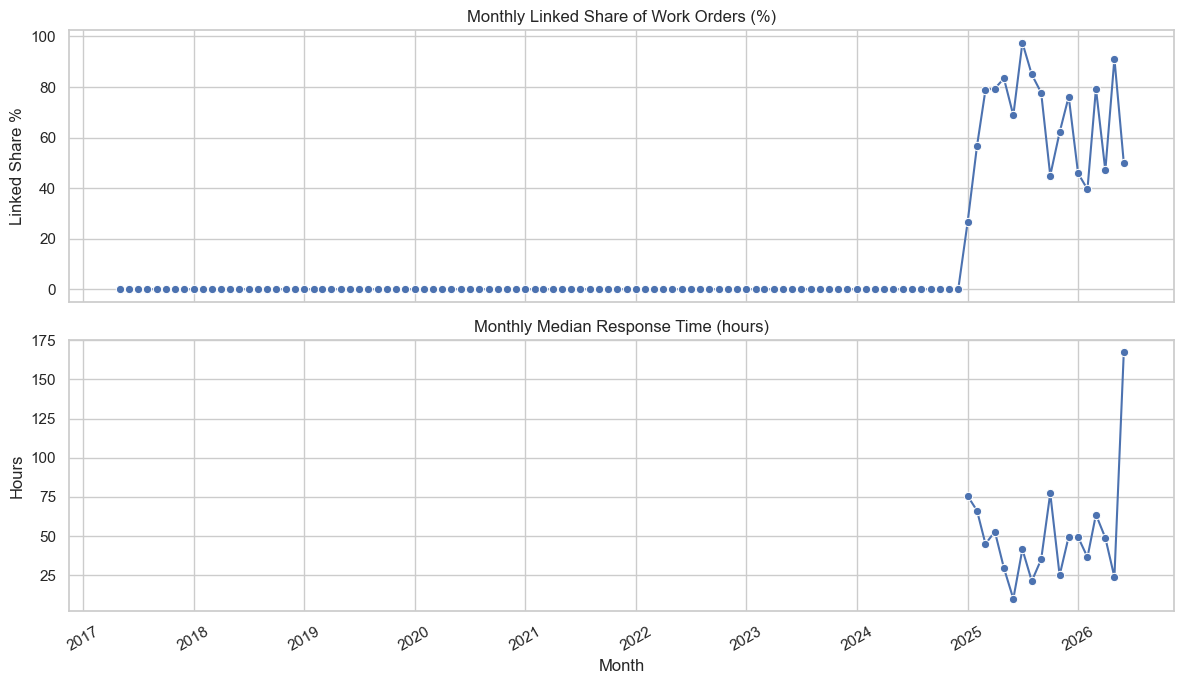

In [16]:
display(contract_kpi)

monthly_linked = (
    kpi_base.dropna(subset=["WORK_STARTED_DATETIME"])
    .assign(month=kpi_base["WORK_STARTED_DATETIME"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", dropna=True)
    .agg(
        work_orders=("WO_NO", "count"),
        linked_share_pct=("linked_flag", lambda s: s.mean() * 100),
        median_response_h=("response_hours", "median"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
sns.lineplot(data=monthly_linked, x="month", y="linked_share_pct", marker="o", ax=axes[0])
axes[0].set_title("Monthly Linked Share of Work Orders (%)")
axes[0].set_ylabel("Linked Share %")

sns.lineplot(data=monthly_linked, x="month", y="median_response_h", marker="o", ax=axes[1])
axes[1].set_title("Monthly Median Response Time (hours)")
axes[1].set_ylabel("Hours")
axes[1].set_xlabel("Month")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Save clean outputs for reporting

This exports a reusable linked table and summary KPI tables to `analysis/outputs`.

In [17]:
outputs_dir = repo_root / "analysis" / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

linked_export_cols = [
    "WO_NO",
    "CUSTOMER_NO",
    "CUSTOMER_SITE_NO",
    "WORK_STARTED_DATETIME",
    "WORK_FINISHED_DATETIME",
    "PRIORITY_ID",
    "CONTRACT",
    "PM_NO",
    "ALERT_EVENT_ID",
    "EVENT_TIME",
    "Priority",
    "EVENT_DESCRIPTION",
    "HWID",
    "response_hours",
]

kpi_base[linked_export_cols].to_csv(outputs_dir / "linked_workorders_alarms.csv", index=False)
priority_kpi.to_csv(outputs_dir / "kpi_priority.csv", index=False)
contract_kpi.to_csv(outputs_dir / "kpi_contract.csv", index=False)
monthly_linked.to_csv(outputs_dir / "kpi_monthly_linked.csv", index=False)

print("Saved files:")
for name in [
    "linked_workorders_alarms.csv",
    "kpi_priority.csv",
    "kpi_contract.csv",
    "kpi_monthly_linked.csv",
]:
    print("-", outputs_dir / name)


Saved files:
- /Users/jyri/repos/hack/analysis/outputs/linked_workorders_alarms.csv
- /Users/jyri/repos/hack/analysis/outputs/kpi_priority.csv
- /Users/jyri/repos/hack/analysis/outputs/kpi_contract.csv
- /Users/jyri/repos/hack/analysis/outputs/kpi_monthly_linked.csv


## Next steps

- Add occupancy files and compare utilization vs work order volume.
- Split response KPIs by contract and priority.
- Save cleaned linkage table into analysis/outputs for reporting.

## Occupancy vs work order demand

This section loads desk and room utilization files, reshapes them from wide to long format, and compares occupancy levels against daily work-order volume.

In [20]:
import glob


def load_occupancy_csv(path: str) -> pd.DataFrame:
    # Some files may contain localized characters; use a safe encoding fallback.
    for enc in ("utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)


def normalize_occupancy(files: list[str], metric_type: str) -> pd.DataFrame:
    frames = []
    for file_path in files:
        df = load_occupancy_csv(file_path)
        if "asset" not in df.columns:
            continue

        long_df = df.melt(id_vars=["asset"], var_name="date", value_name="utilization_pct")
        long_df["date"] = pd.to_datetime(long_df["date"], errors="coerce")
        long_df["utilization_pct"] = pd.to_numeric(long_df["utilization_pct"], errors="coerce")
        long_df = long_df.dropna(subset=["date", "utilization_pct"])

        long_df["metric_type"] = metric_type
        long_df["source_file"] = Path(file_path).name
        frames.append(long_df)

    if not frames:
        return pd.DataFrame(columns=["asset", "date", "utilization_pct", "metric_type", "source_file"])

    combined = pd.concat(frames, ignore_index=True)
    combined = combined.drop_duplicates(subset=["asset", "date", "metric_type"], keep="first")
    return combined


desk_files = sorted(
    p for p in glob.glob(str(repo_root / "rawdata" / "need-based cleaning" / "**" / "*desk_utilization*.csv"), recursive=True)
    if ":Zone.Identifier" not in p
)
room_files = sorted(
    p for p in glob.glob(str(repo_root / "rawdata" / "need-based cleaning" / "**" / "*Room_Utilization*.csv"), recursive=True)
    if ":Zone.Identifier" not in p
)

desk_long = normalize_occupancy(desk_files, "desk")
room_long = normalize_occupancy(room_files, "room")
occupancy_long = pd.concat([desk_long, room_long], ignore_index=True)

print(f"Desk files loaded: {len(desk_files)}")
print(f"Room files loaded: {len(room_files)}")
print(f"Occupancy rows: {len(occupancy_long):,}")
occupancy_long.head()


Desk files loaded: 10
Room files loaded: 10
Occupancy rows: 134,392


,asset,date,utilization_pct,metric_type,source_file
0,2.krs Desk 7,2025-12-01,0.00,desk,Valmet_desk_utilization_0101225-280226.csv
1,desk 115,2025-12-01,51.17,desk,Valmet_desk_utilization_0101225-280226.csv
2,desk 104,2025-12-01,67.50,desk,Valmet_desk_utilization_0101225-280226.csv
3,Desk 48,2025-12-01,0.00,desk,Valmet_desk_utilization_0101225-280226.csv
4,DEsk 35,2025-12-01,0.00,desk,Valmet_desk_utilization_0101225-280226.csv


In [21]:
occupancy_daily = (
    occupancy_long.groupby(["date", "metric_type"], dropna=False)
    .agg(
        avg_utilization_pct=("utilization_pct", "mean"),
        asset_count=("asset", "nunique"),
    )
    .reset_index()
)

work_daily = (
    df_work.assign(work_day=pd.to_datetime(df_work["WORK_STARTED_DATETIME"], errors="coerce", dayfirst=True))
    .dropna(subset=["work_day"])
    .assign(date=lambda d: d["work_day"].dt.normalize())
    .groupby("date", dropna=False)
    .agg(
        work_orders=("WO_NO", "count"),
        cleaning_work_orders=("CONTRACT", lambda s: (s == "SP").sum()),
    )
    .reset_index()
)

occ_vs_work = occupancy_daily.merge(work_daily, on="date", how="left")
occ_vs_work[["work_orders", "cleaning_work_orders"]] = occ_vs_work[["work_orders", "cleaning_work_orders"]].fillna(0)

occ_vs_work.head()


,date,metric_type,avg_utilization_pct,asset_count,work_orders,cleaning_work_orders
0,2024-01-01,desk,0.000000,176,3.0,0.0
1,2024-01-01,room,0.000000,38,3.0,0.0
2,2024-01-02,desk,25.879943,176,25.0,18.0
3,2024-01-02,room,19.546579,38,25.0,18.0
4,2024-01-03,desk,29.577045,176,25.0,18.0


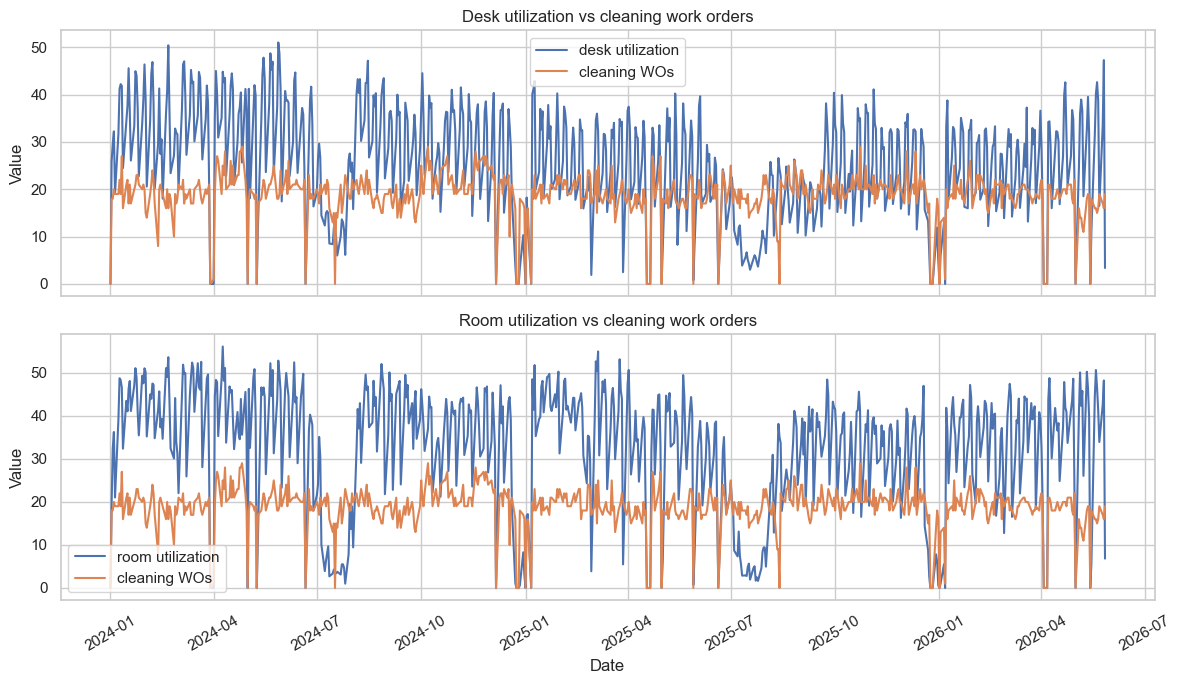

,metric_type,corr_with_work_orders,corr_with_cleaning_wos
0,desk,0.557558,0.499113
1,room,0.557798,0.496773


In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for i, metric in enumerate(["desk", "room"]):
    temp = occ_vs_work[occ_vs_work["metric_type"] == metric].sort_values("date")
    sns.lineplot(data=temp, x="date", y="avg_utilization_pct", ax=axes[i], label=f"{metric} utilization")
    sns.lineplot(data=temp, x="date", y="cleaning_work_orders", ax=axes[i], label="cleaning WOs")
    axes[i].set_title(f"{metric.capitalize()} utilization vs cleaning work orders")
    axes[i].set_ylabel("Value")

axes[-1].set_xlabel("Date")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

corr_summary = (
    occ_vs_work.groupby("metric_type", dropna=False)
    .apply(lambda x: pd.Series({
        "corr_with_work_orders": x["avg_utilization_pct"].corr(x["work_orders"]),
        "corr_with_cleaning_wos": x["avg_utilization_pct"].corr(x["cleaning_work_orders"]),
    }))
    .reset_index()
)

corr_summary


In [23]:
occ_output_cols = [
    "date",
    "metric_type",
    "avg_utilization_pct",
    "asset_count",
    "work_orders",
    "cleaning_work_orders",
]

occ_vs_work[occ_output_cols].to_csv(outputs_dir / "occupancy_vs_workorders_daily.csv", index=False)
print("Saved:", outputs_dir / "occupancy_vs_workorders_daily.csv")


Saved: /Users/jyri/repos/hack/analysis/outputs/occupancy_vs_workorders_daily.csv


## Lag analysis: does occupancy lead cleaning demand?

This tests whether occupancy is more predictive of cleaning work orders on the same day or after a delay (0 to 10 days).

In [24]:
lag_base = (
    occ_vs_work.pivot_table(
        index="date",
        columns="metric_type",
        values="avg_utilization_pct",
        aggfunc="mean",
    )
    .reset_index()
    .merge(
        occ_vs_work.groupby("date", dropna=False)["cleaning_work_orders"].max().reset_index(),
        on="date",
        how="left",
    )
    .sort_values("date")
)

lag_rows = []
for lag_days in range(0, 11):
    tmp = lag_base.copy()
    tmp["desk_lagged"] = tmp["desk"].shift(lag_days)
    tmp["room_lagged"] = tmp["room"].shift(lag_days)

    desk_corr = tmp["desk_lagged"].corr(tmp["cleaning_work_orders"])
    room_corr = tmp["room_lagged"].corr(tmp["cleaning_work_orders"])

    lag_rows.append(
        {
            "lag_days": lag_days,
            "desk_corr": desk_corr,
            "room_corr": room_corr,
        }
    )

lag_corr = pd.DataFrame(lag_rows)
lag_corr


,lag_days,desk_corr,room_corr
0,0,0.499113,0.496773
1,1,0.283466,0.312505
2,2,0.126116,0.148123
3,3,0.097575,0.120833
4,4,0.107230,0.104703
5,5,0.166390,0.163460
6,6,0.109979,0.112273
7,7,0.033726,0.051218
8,8,0.056504,0.070156
9,9,0.088743,0.082927


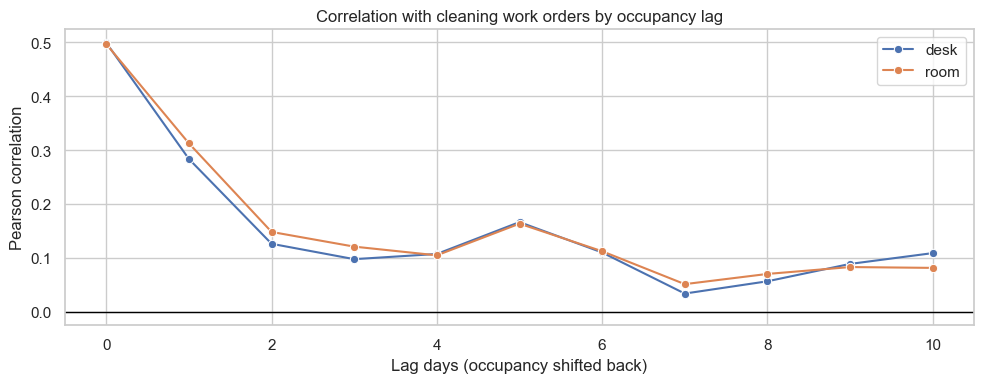

,lag_days,desk_corr,room_corr
0,0,0.499113,0.496773
1,1,0.283466,0.312505
5,5,0.166390,0.163460


In [25]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=lag_corr, x="lag_days", y="desk_corr", marker="o", label="desk")
sns.lineplot(data=lag_corr, x="lag_days", y="room_corr", marker="o", label="room")
plt.axhline(0, color="black", linewidth=1)
plt.title("Correlation with cleaning work orders by occupancy lag")
plt.xlabel("Lag days (occupancy shifted back)")
plt.ylabel("Pearson correlation")
plt.tight_layout()
plt.show()

lag_corr.sort_values("desk_corr", ascending=False).head(3)


## Baseline forecast: naive vs occupancy-informed

This builds a lightweight daily forecast for cleaning work orders and compares:
- naive baseline: yesterday's 7-day rolling average
- occupancy-informed baseline: linear model using lagged desk and room utilization

,model,mae,best_lag_used_days
0,naive_7d_rolling,3.610286,0
1,occupancy_linear,3.188305,0


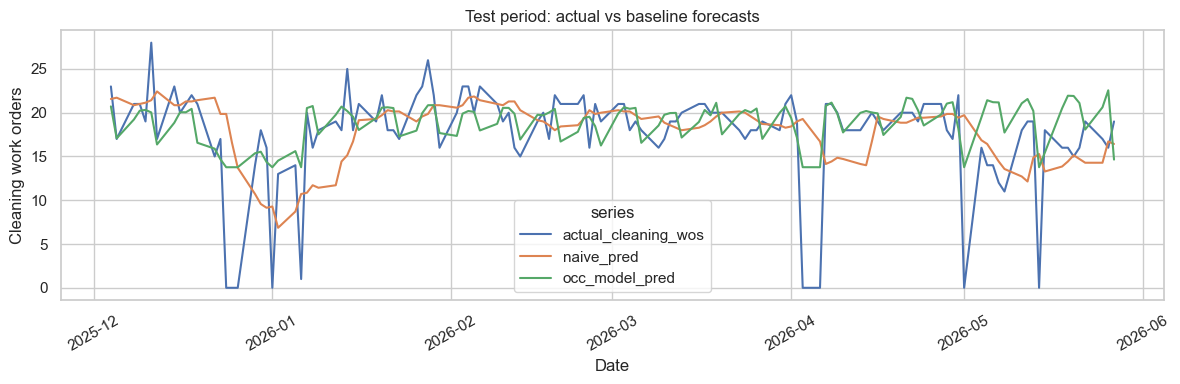

,model,mae,best_lag_used_days
0,naive_7d_rolling,3.610286,0
1,occupancy_linear,3.188305,0


In [26]:
import numpy as np

best_lag = int(lag_corr.sort_values("desk_corr", ascending=False).iloc[0]["lag_days"])
model_df = lag_base.copy()
model_df["desk_feat"] = model_df["desk"].shift(best_lag)
model_df["room_feat"] = model_df["room"].shift(best_lag)
model_df["target"] = model_df["cleaning_work_orders"]
model_df["naive_pred"] = model_df["target"].rolling(7).mean().shift(1)

model_df = model_df.dropna(subset=["desk_feat", "room_feat", "target", "naive_pred"]).copy()

split_idx = int(len(model_df) * 0.8)
train = model_df.iloc[:split_idx].copy()
test = model_df.iloc[split_idx:].copy()

X_train = np.column_stack([np.ones(len(train)), train["desk_feat"].values, train["room_feat"].values])
y_train = train["target"].values
beta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)

X_test = np.column_stack([np.ones(len(test)), test["desk_feat"].values, test["room_feat"].values])
test["occ_model_pred"] = X_test @ beta

naive_mae = (test["target"] - test["naive_pred"]).abs().mean()
occ_mae = (test["target"] - test["occ_model_pred"]).abs().mean()

comparison = pd.DataFrame(
    {
        "model": ["naive_7d_rolling", "occupancy_linear"],
        "mae": [naive_mae, occ_mae],
        "best_lag_used_days": [best_lag, best_lag],
    }
)

display(comparison)

plt.figure(figsize=(12, 4))
plot_df = test[["date", "target", "naive_pred", "occ_model_pred"]].copy()
plot_df = plot_df.rename(columns={"target": "actual_cleaning_wos"})
plot_df = plot_df.melt(id_vars=["date"], var_name="series", value_name="value")
sns.lineplot(data=plot_df, x="date", y="value", hue="series")
plt.title("Test period: actual vs baseline forecasts")
plt.xlabel("Date")
plt.ylabel("Cleaning work orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

comparison


In [27]:
lag_corr.to_csv(outputs_dir / "occupancy_lag_correlation.csv", index=False)
comparison.to_csv(outputs_dir / "cleaning_forecast_baseline_comparison.csv", index=False)
test[["date", "target", "naive_pred", "occ_model_pred"]].to_csv(
    outputs_dir / "cleaning_forecast_test_predictions.csv", index=False
)

print("Saved:")
print("-", outputs_dir / "occupancy_lag_correlation.csv")
print("-", outputs_dir / "cleaning_forecast_baseline_comparison.csv")
print("-", outputs_dir / "cleaning_forecast_test_predictions.csv")

Saved:
- /Users/jyri/repos/hack/analysis/outputs/occupancy_lag_correlation.csv
- /Users/jyri/repos/hack/analysis/outputs/cleaning_forecast_baseline_comparison.csv
- /Users/jyri/repos/hack/analysis/outputs/cleaning_forecast_test_predictions.csv


## Calendar-aware baseline (weekday and seasonality)

This extends the occupancy baseline with calendar effects:
- weekday indicators (Mon-Sun)
- cyclic month seasonality (`sin` / `cos`)

Goal: check whether cleaning demand is better explained when occupancy and calendar patterns are combined.

In [31]:
cal_df = lag_base.copy()
cal_df["desk_feat"] = cal_df["desk"].shift(best_lag)
cal_df["room_feat"] = cal_df["room"].shift(best_lag)
cal_df["target"] = cal_df["cleaning_work_orders"]
cal_df["naive_pred"] = cal_df["target"].rolling(7).mean().shift(1)

cal_df["dow"] = cal_df["date"].dt.dayofweek
cal_df["month"] = cal_df["date"].dt.month
cal_df["month_sin"] = np.sin(2 * np.pi * cal_df["month"] / 12)
cal_df["month_cos"] = np.cos(2 * np.pi * cal_df["month"] / 12)

cal_df = cal_df.dropna(subset=["desk_feat", "room_feat", "target", "naive_pred"]).copy()

split_idx = int(len(cal_df) * 0.8)
cal_train = cal_df.iloc[:split_idx].copy()
cal_test = cal_df.iloc[split_idx:].copy()

# Occupancy-only linear baseline
X_occ_train = np.column_stack([
    np.ones(len(cal_train)),
    cal_train["desk_feat"].values,
    cal_train["room_feat"].values,
]).astype(float)
y_train = cal_train["target"].astype(float).values
beta_occ, *_ = np.linalg.lstsq(X_occ_train, y_train, rcond=None)

X_occ_test = np.column_stack([
    np.ones(len(cal_test)),
    cal_test["desk_feat"].values,
    cal_test["room_feat"].values,
]).astype(float)
cal_test["occ_model_pred"] = X_occ_test @ beta_occ

# Occupancy + calendar model
X_cal_train = pd.get_dummies(
    cal_train[["desk_feat", "room_feat", "month_sin", "month_cos", "dow"]],
    columns=["dow"],
    drop_first=True,
)
X_cal_test = pd.get_dummies(
    cal_test[["desk_feat", "room_feat", "month_sin", "month_cos", "dow"]],
    columns=["dow"],
    drop_first=True,
)
X_cal_test = X_cal_test.reindex(columns=X_cal_train.columns, fill_value=0)

X_cal_train_np = np.column_stack([np.ones(len(X_cal_train)), X_cal_train.values]).astype(float)
X_cal_test_np = np.column_stack([np.ones(len(X_cal_test)), X_cal_test.values]).astype(float)

beta_cal, *_ = np.linalg.lstsq(X_cal_train_np, y_train, rcond=None)
cal_test["occ_calendar_pred"] = X_cal_test_np @ beta_cal

# Optional clipping for demand forecasts
for col in ["naive_pred", "occ_model_pred", "occ_calendar_pred"]:
    cal_test[col] = cal_test[col].clip(lower=0)

comparison_extended = pd.DataFrame(
    {
        "model": ["naive_7d_rolling", "occupancy_linear", "occupancy_calendar"],
        "mae": [
            (cal_test["target"] - cal_test["naive_pred"]).abs().mean(),
            (cal_test["target"] - cal_test["occ_model_pred"]).abs().mean(),
            (cal_test["target"] - cal_test["occ_calendar_pred"]).abs().mean(),
        ],
        "best_lag_used_days": [best_lag, best_lag, best_lag],
    }
)

comparison_extended.sort_values("mae")

,model,mae,best_lag_used_days
2,occupancy_calendar,3.156633,0
1,occupancy_linear,3.188305,0
0,naive_7d_rolling,3.610286,0


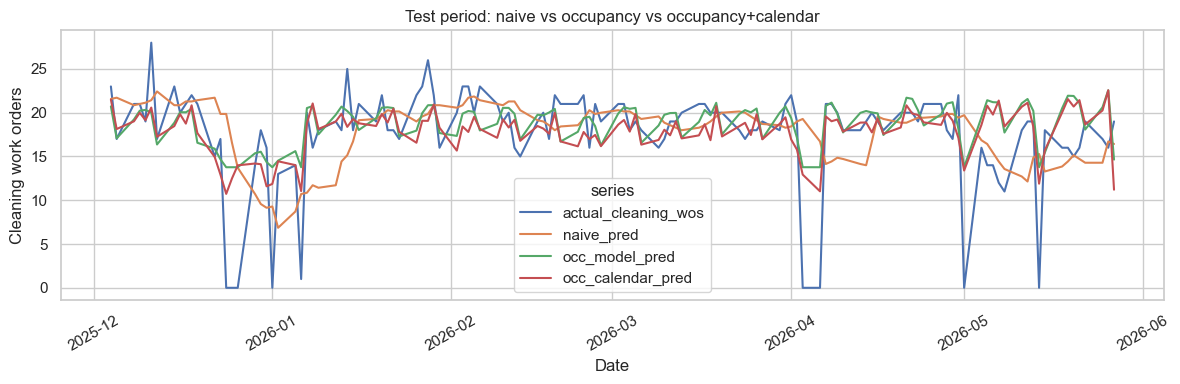

,model,mae,best_lag_used_days
2,occupancy_calendar,3.156633,0
1,occupancy_linear,3.188305,0
0,naive_7d_rolling,3.610286,0


In [32]:
plt.figure(figsize=(12, 4))
plot_df = cal_test[["date", "target", "naive_pred", "occ_model_pred", "occ_calendar_pred"]].copy()
plot_df = plot_df.rename(columns={"target": "actual_cleaning_wos"})
plot_df = plot_df.melt(id_vars=["date"], var_name="series", value_name="value")

sns.lineplot(data=plot_df, x="date", y="value", hue="series")
plt.title("Test period: naive vs occupancy vs occupancy+calendar")
plt.xlabel("Date")
plt.ylabel("Cleaning work orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

comparison_extended.sort_values("mae")


In [33]:
comparison_extended.to_csv(outputs_dir / "cleaning_forecast_calendar_comparison.csv", index=False)
cal_test[["date", "target", "naive_pred", "occ_model_pred", "occ_calendar_pred"]].to_csv(
    outputs_dir / "cleaning_forecast_calendar_test_predictions.csv", index=False
)

print("Saved:")
print("-", outputs_dir / "cleaning_forecast_calendar_comparison.csv")
print("-", outputs_dir / "cleaning_forecast_calendar_test_predictions.csv")

Saved:
- /Users/jyri/repos/hack/analysis/outputs/cleaning_forecast_calendar_comparison.csv
- /Users/jyri/repos/hack/analysis/outputs/cleaning_forecast_calendar_test_predictions.csv


## Anomaly days for operations storytelling

This section highlights dates where observed cleaning work orders diverge sharply from the best-performing baseline (`occupancy_calendar`).

In [34]:
anom = cal_test[["date", "target", "naive_pred", "occ_model_pred", "occ_calendar_pred"]].copy()
anom["residual_calendar"] = anom["target"] - anom["occ_calendar_pred"]
anom["abs_residual_calendar"] = anom["residual_calendar"].abs()

res_std = anom["residual_calendar"].std()
if pd.notna(res_std) and res_std > 0:
    anom["residual_zscore"] = anom["residual_calendar"] / res_std
else:
    anom["residual_zscore"] = 0.0

anom["anomaly_flag"] = anom["residual_zscore"].abs() >= 2.0

top_anomalies = anom.sort_values("abs_residual_calendar", ascending=False).head(15)

display(top_anomalies[[
    "date",
    "target",
    "occ_calendar_pred",
    "residual_calendar",
    "residual_zscore",
    "anomaly_flag",
]])

print("Anomaly days (|z| >= 2):", int(anom["anomaly_flag"].sum()))

,date,target,occ_calendar_pred,residual_calendar,residual_zscore,anomaly_flag
519,2025-12-26,0.0,13.988281,-13.988281,-3.111427,True
609,2026-05-01,0.0,13.396333,-13.396333,-2.979760,True
589,2026-04-03,0.0,12.931724,-12.931724,-2.876416,True
518,2025-12-25,0.0,12.489826,-12.489826,-2.778124,True
618,2026-05-14,0.0,11.895930,-11.895930,-2.646023,True
523,2026-01-01,0.0,11.863853,-11.863853,-2.638888,True
590,2026-04-06,0.0,11.019763,-11.019763,-2.451137,True
517,2025-12-24,0.0,10.728507,-10.728507,-2.386352,True
526,2026-01-06,1.0,11.049197,-10.049197,-2.235253,True
613,2026-05-07,12.0,21.388533,-9.388533,-2.088301,True


Anomaly days (|z| >= 2): 10


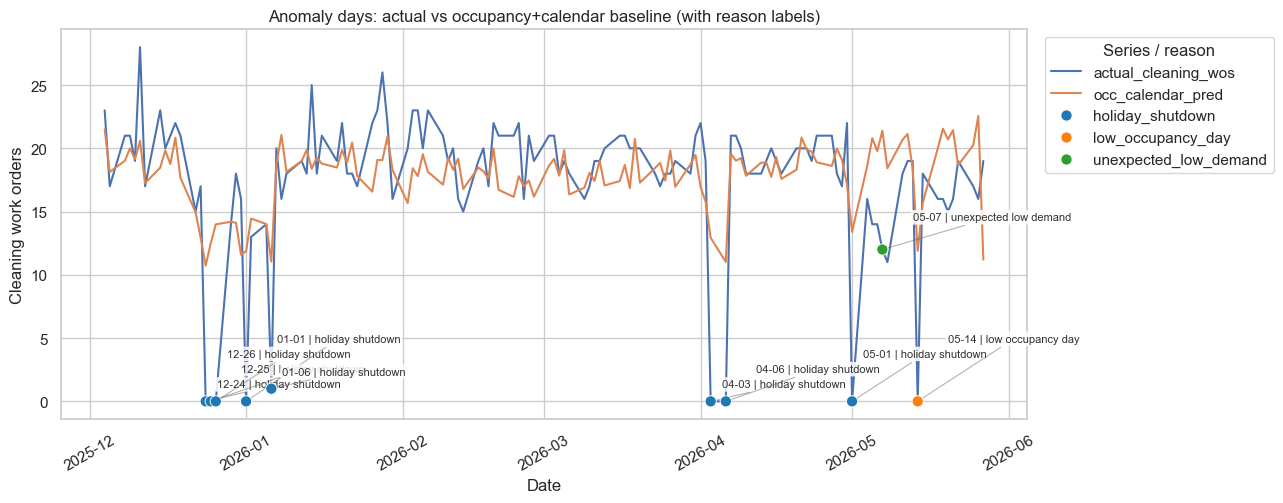

In [41]:
plt.figure(figsize=(13, 5.2))
plot_anom = anom.copy()
plot_anom["is_anomaly"] = plot_anom["anomaly_flag"].map({True: "anomaly", False: "normal"})

# Prefer reason labels computed in the reason-code section, but keep a safe fallback.
reason_map = pd.DataFrame(columns=["date", "likely_reason"])
if "anomaly_reason_table" in globals() and "likely_reason" in anomaly_reason_table.columns:
    reason_map = anomaly_reason_table[["date", "likely_reason"]].drop_duplicates()
elif "anomaly_features" in globals() and "likely_reason" in anomaly_features.columns:
    reason_map = anomaly_features[["date", "likely_reason"]].drop_duplicates()

plot_anom = plot_anom.merge(reason_map, on="date", how="left")
plot_anom["likely_reason"] = plot_anom["likely_reason"].fillna("anomaly_day")

sns.lineplot(data=plot_anom, x="date", y="target", label="actual_cleaning_wos")
sns.lineplot(data=plot_anom, x="date", y="occ_calendar_pred", label="occ_calendar_pred")

anom_points = plot_anom[plot_anom["anomaly_flag"]].copy().sort_values(["target", "date"])
sns.scatterplot(
    data=anom_points,
    x="date",
    y="target",
    hue="likely_reason",
    s=65,
    palette="tab10",
    zorder=4,
)

# Add readable boxed labels with staggered offsets to reduce overlap.
for i, (_, row) in enumerate(anom_points.iterrows()):
    label = f"{row['date']:%m-%d} | {row['likely_reason'].replace('_', ' ')}"
    offset_x = 8 + (i % 2) * 14
    offset_y = 10 + (i % 4) * 11
    plt.annotate(
        label,
        (row["date"], row["target"]),
        textcoords="offset points",
        xytext=(offset_x, offset_y),
        fontsize=8,
        alpha=0.95,
        bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "none", "alpha": 0.85},
        arrowprops={"arrowstyle": "-", "color": "0.4", "alpha": 0.5, "lw": 0.8},
    )

plt.title("Anomaly days: actual vs occupancy+calendar baseline (with reason labels)")
plt.xlabel("Date")
plt.ylabel("Cleaning work orders")
plt.xticks(rotation=30)
plt.legend(title="Series / reason", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [36]:
anom.to_csv(outputs_dir / "cleaning_demand_anomaly_days.csv", index=False)
top_anomalies.to_csv(outputs_dir / "cleaning_demand_top_anomalies.csv", index=False)

print("Saved:")
print("-", outputs_dir / "cleaning_demand_anomaly_days.csv")
print("-", outputs_dir / "cleaning_demand_top_anomalies.csv")

Saved:
- /Users/jyri/repos/hack/analysis/outputs/cleaning_demand_anomaly_days.csv
- /Users/jyri/repos/hack/analysis/outputs/cleaning_demand_top_anomalies.csv


## Reason codes for anomaly days

This section adds interpretable context per anomaly date:
- weekday / weekend
- selected Finnish holiday flags
- daily alarm volume compared to baseline
- occupancy level compared to baseline

The output proposes a simple `likely_reason` label for each flagged day.

In [37]:
# Lightweight Finnish holiday set for 2025-2026 (sufficient for hackathon storytelling)
fi_holidays = pd.to_datetime([
    "2025-01-01", "2025-01-06", "2025-04-18", "2025-04-21", "2025-05-01",
    "2025-06-20", "2025-12-24", "2025-12-25", "2025-12-26",
    "2026-01-01", "2026-01-06", "2026-04-03", "2026-04-06", "2026-05-01",
    "2026-06-19", "2026-12-24", "2026-12-25", "2026-12-26",
]).normalize()

alarm_daily = (
    df_alarms.assign(date=pd.to_datetime(df_alarms["EVENT_TIME"], errors="coerce").dt.normalize())
    .dropna(subset=["date"])
    .groupby("date", dropna=False)
    .size()
    .rename("alarm_count")
    .reset_index()
)

anomaly_features = anom.merge(alarm_daily, on="date", how="left")
anomaly_features["alarm_count"] = anomaly_features["alarm_count"].fillna(0)
anomaly_features = anomaly_features.merge(
    lag_base[["date", "desk", "room"]].rename(columns={"desk": "desk_util", "room": "room_util"}),
    on="date",
    how="left",
)

anomaly_features["weekday"] = anomaly_features["date"].dt.day_name()
anomaly_features["is_weekend"] = anomaly_features["date"].dt.dayofweek >= 5
anomaly_features["is_fi_holiday"] = anomaly_features["date"].isin(fi_holidays)

alarm_p75 = anomaly_features["alarm_count"].quantile(0.75)
desk_p25 = anomaly_features["desk_util"].quantile(0.25)
room_p25 = anomaly_features["room_util"].quantile(0.25)


In [38]:
def classify_reason(row):
    if not row.get("anomaly_flag", False):
        return "normal_variation"

    if row["is_fi_holiday"] and row["target"] <= 1:
        return "holiday_shutdown"
    if row["is_weekend"] and row["target"] <= 1:
        return "weekend_shutdown"
    if row["alarm_count"] >= alarm_p75 and row["residual_calendar"] > 0:
        return "alarm_spike_or_incident"
    if (row["desk_util"] <= desk_p25 or row["room_util"] <= room_p25) and row["residual_calendar"] < 0:
        return "low_occupancy_day"
    if row["residual_calendar"] > 0:
        return "unexpected_high_demand"
    return "unexpected_low_demand"

anomaly_features["likely_reason"] = anomaly_features.apply(classify_reason, axis=1)

anomaly_reason_table = anomaly_features[
    anomaly_features["anomaly_flag"]
].sort_values("abs_residual_calendar", ascending=False)[[
    "date",
    "weekday",
    "target",
    "occ_calendar_pred",
    "residual_calendar",
    "alarm_count",
    "desk_util",
    "room_util",
    "is_fi_holiday",
    "is_weekend",
    "likely_reason",
]]

display(anomaly_reason_table)
anomaly_reason_table["likely_reason"].value_counts().to_frame("count")

,date,weekday,target,occ_calendar_pred,residual_calendar,alarm_count,desk_util,room_util,is_fi_holiday,is_weekend,likely_reason
16,2025-12-26,Friday,0.0,13.988281,-13.988281,0.0,0.000000,0.000000,True,False,holiday_shutdown
106,2026-05-01,Friday,0.0,13.396333,-13.396333,45.0,0.000000,0.026316,True,False,holiday_shutdown
86,2026-04-03,Friday,0.0,12.931724,-12.931724,0.0,0.009489,0.035000,True,False,holiday_shutdown
15,2025-12-25,Thursday,0.0,12.489826,-12.489826,0.0,0.000000,0.000000,True,False,holiday_shutdown
115,2026-05-14,Thursday,0.0,11.895930,-11.895930,12.0,0.000000,0.000000,False,False,low_occupancy_day
20,2026-01-01,Thursday,0.0,11.863853,-11.863853,0.0,0.000000,0.000000,True,False,holiday_shutdown
87,2026-04-06,Monday,0.0,11.019763,-11.019763,0.0,0.000000,0.000000,True,False,holiday_shutdown
14,2025-12-24,Wednesday,0.0,10.728507,-10.728507,12.0,0.000000,0.000000,True,False,holiday_shutdown
23,2026-01-06,Tuesday,1.0,11.049197,-10.049197,0.0,0.000000,0.000000,True,False,holiday_shutdown
110,2026-05-07,Thursday,12.0,21.388533,-9.388533,84.0,36.485114,45.801579,False,False,unexpected_low_demand


,count
likely_reason,
holiday_shutdown,8
low_occupancy_day,1
unexpected_low_demand,1


In [39]:
anomaly_reason_table.to_csv(outputs_dir / "cleaning_demand_anomaly_reason_codes.csv", index=False)

print("Saved:")
print("-", outputs_dir / "cleaning_demand_anomaly_reason_codes.csv")

Saved:
- /Users/jyri/repos/hack/analysis/outputs/cleaning_demand_anomaly_reason_codes.csv
